# Titanic Survival Modeling

타이타닉 승객의 생존 여부를 예측하는 이진 분류 실험이다. 내부 hold-out은 마지막에 한 번만 평가하고, Kaggle test 데이터는 정답이 없으므로 제출 예측 생성에만 사용한다.

## 1. 설정 및 데이터 로드

모든 난수 시드는 42로 고정한다. 노트북을 프로젝트 루트와 `notebooks/` 어디에서 실행해도 동일한 데이터 경로를 사용한다.

In [1]:
import os
os.environ.setdefault('LOKY_MAX_CPU_COUNT', str(max((os.cpu_count() or 2) // 2, 1)))

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV, StratifiedKFold, cross_val_predict, cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

SEED = 42
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
ASSET_DIR = PROJECT_ROOT / 'assets'
ASSET_DIR.mkdir(exist_ok=True)

train_df = pd.read_csv(DATA_DIR / 'titanic_train.csv')
kaggle_test_df = pd.read_csv(DATA_DIR / 'titanic_test.csv')

print('train:', train_df.shape, 'kaggle test:', kaggle_test_df.shape)
train_df.head()

train: (891, 12) kaggle test: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. 내부 hold-out 분리와 EDA

전체 실험 전에 `titanic_train.csv`를 개발용 80%와 내부 hold-out 20%로 나눈다. EDA와 교차검증은 개발용 데이터에만 사용한다.

In [2]:
X = train_df.drop(columns='Survived')
y = train_df['Survived']

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

eda_df = X_train.assign(Survived=y_train)
print('development:', X_train.shape, 'hold-out:', X_holdout.shape)
print('missing values (development)')
display(eda_df.isna().sum().sort_values(ascending=False).head())
display(eda_df.groupby('Sex')['Survived'].agg(['count', 'mean']))
display(eda_df.groupby('Pclass')['Survived'].agg(['count', 'mean']))

development: (712, 11) hold-out: (179, 11)
missing values (development)


Cabin          552
Age            137
Embarked         2
PassengerId      0
Sex              0
dtype: int64

,count,mean
Sex,,
female,253,0.743083
male,459,0.185185


,count,mean
Pclass,,
1,171,0.649123
2,150,0.446667
3,391,0.242967


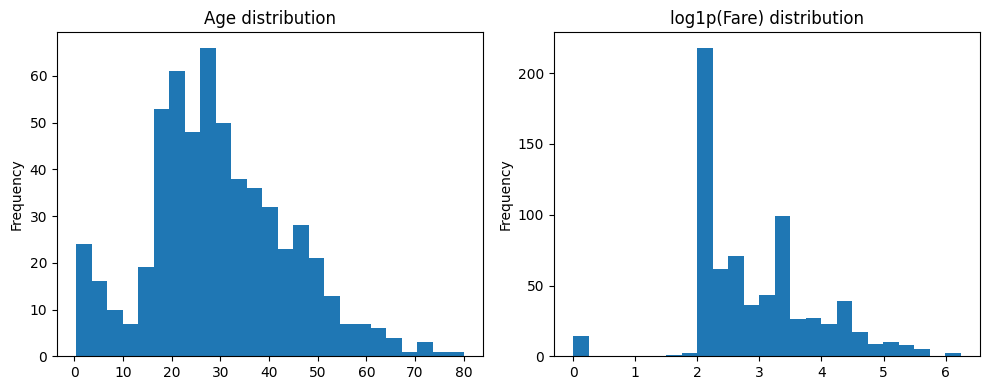

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
eda_df['Age'].plot.hist(bins=25, ax=axes[0], title='Age distribution')
np.log1p(eda_df['Fare']).plot.hist(bins=25, ax=axes[1], title='log1p(Fare) distribution')
plt.tight_layout()
plt.show()

성별과 객실 등급별 생존율 차이가 크고, 운임은 오른쪽 꼬리가 길다. 따라서 범주형 변수는 one-hot encoding하고 `Fare`에는 `log1p`를 적용한다.

## 3. 전처리와 베이스라인 모델 비교

결측치 처리와 인코딩은 Pipeline 안에서 학습 Fold별로 수행한다. LR·RF·HGB·XGB를 동일한 5-Fold 기준으로 비교한다.

In [4]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
fare_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler()),
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

baseline_preprocessor = ColumnTransformer([
    ('num', numeric_transformer, ['Age', 'SibSp', 'Parch']),
    ('fare', fare_transformer, ['Fare']),
    ('cat', categorical_transformer, ['Pclass', 'Sex', 'Embarked']),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

In [5]:
baseline_models = {
    'LR': LogisticRegression(max_iter=1000, random_state=SEED),
    'RF': RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    'HGB': HistGradientBoostingClassifier(random_state=SEED),
    'XGB': XGBClassifier(
        n_estimators=300, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, eval_metric='logloss',
        random_state=SEED, n_jobs=-1,
    ),
}

baseline_rows = []
for name, model in baseline_models.items():
    result = cross_validate(
        Pipeline([('preprocessor', baseline_preprocessor), ('model', model)]),
        X_train, y_train, cv=cv, scoring=scoring,
    )
    baseline_rows.append({
        'model': name,
        **{metric: result[f'test_{metric}'].mean() for metric in scoring},
    })

baseline_comparison = pd.DataFrame(baseline_rows).set_index('model')
baseline_comparison.round(3)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
LR,0.791,0.748,0.692,0.717,0.858
RF,0.802,0.756,0.718,0.736,0.863
HGB,0.820,0.796,0.718,0.755,0.877
XGB,0.824,0.805,0.721,0.760,0.883


## 4. 피처 실험

가족 규모(`FamilySize`), 혼자 탑승 여부(`IsAlone`), 이름의 호칭(`Title`)을 추가한다. 모두 한 승객의 행만으로 계산되므로 교차검증 전에 생성해도 target 누수는 없다.

In [6]:
def add_context_features(df):
    result = df.copy()
    result['FamilySize'] = result['SibSp'] + result['Parch'] + 1
    result['IsAlone'] = (result['FamilySize'] == 1).astype(int)
    title = result['Name'].str.extract(r',\s*([^.]*)\.', expand=False)
    result['Title'] = title.where(title.isin(['Mr', 'Miss', 'Mrs', 'Master']), 'Rare')
    return result

X_train_context = add_context_features(X_train)
X_holdout_context = add_context_features(X_holdout)

context_preprocessor = ColumnTransformer([
    ('num', numeric_transformer, ['Age', 'FamilySize', 'IsAlone']),
    ('fare', fare_transformer, ['Fare']),
    ('cat', categorical_transformer, ['Pclass', 'Sex', 'Embarked', 'Title']),
])

X_train_context[['FamilySize', 'IsAlone', 'Title']].head()

,FamilySize,IsAlone,Title
692,1,1,Mr
481,1,1,Mr
527,1,1,Mr
855,2,0,Mrs
801,3,0,Mrs


,accuracy,precision,recall,f1,roc_auc
model,,,,,
LR,0.820,0.786,0.736,0.759,0.871
RF,0.802,0.742,0.744,0.742,0.870
HGB,0.833,0.807,0.744,0.773,0.886
XGB,0.829,0.806,0.733,0.766,0.894


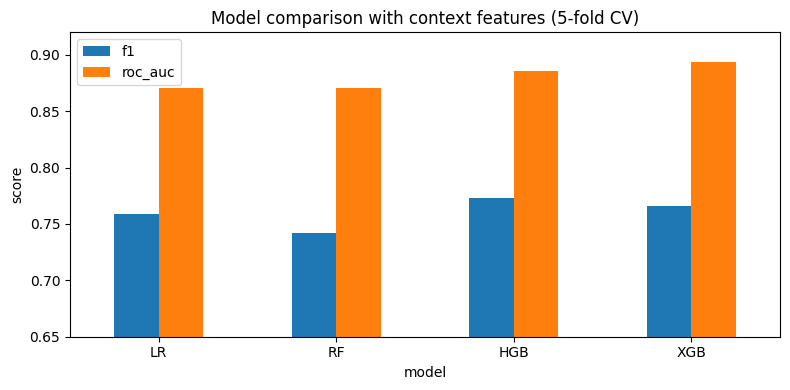

In [7]:
feature_rows = []
for name, model in baseline_models.items():
    result = cross_validate(
        Pipeline([('preprocessor', context_preprocessor), ('model', model)]),
        X_train_context, y_train, cv=cv, scoring=scoring,
    )
    feature_rows.append({
        'model': name,
        **{metric: result[f'test_{metric}'].mean() for metric in scoring},
    })

model_comparison = pd.DataFrame(feature_rows).set_index('model')
display(model_comparison.round(3))

ax = model_comparison[['f1', 'roc_auc']].plot.bar(figsize=(8, 4), ylim=(0.65, 0.92))
ax.set_title('Model comparison with context features (5-fold CV)')
ax.set_ylabel('score')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(ASSET_DIR / 'model_comparison.png', dpi=150)
plt.show()

## 5. Random Forest 튜닝

모델 간 비교 후 Random Forest의 과적합 제어 파라미터를 F1 기준으로 탐색한다. 내부 hold-out은 이 과정에 사용하지 않는다.

In [8]:
rf_pipeline = Pipeline([
    ('preprocessor', context_preprocessor),
    ('model', RandomForestClassifier(random_state=SEED, n_jobs=-1)),
])
rf_param_distributions = {
    'model__n_estimators': [300, 500, 800],
    'model__max_depth': [None, 5, 8, 12, 16, 20],
    'model__min_samples_split': [2, 5, 10, 15, 20],
    'model__min_samples_leaf': [1, 2, 3, 5, 8],
    'model__max_features': ['sqrt', 'log2', 0.5, 0.8],
    'model__class_weight': [None, 'balanced', 'balanced_subsample'],
    'model__max_samples': [None, 0.7, 0.9],
}
rf_search = RandomizedSearchCV(
    rf_pipeline, rf_param_distributions, n_iter=40, scoring=scoring,
    refit='f1', cv=cv, random_state=SEED,
)
_ = rf_search.fit(X_train_context, y_train)

print('best CV F1:', round(rf_search.best_score_, 3))
rf_search.best_params_

best CV F1: 0.774


{'model__n_estimators': 800,
 'model__min_samples_split': 15,
 'model__min_samples_leaf': 2,
 'model__max_samples': None,
 'model__max_features': 'sqrt',
 'model__max_depth': 12,
 'model__class_weight': 'balanced_subsample'}

## 6. Ticket 피처와 threshold 선택

`TicketGroupSize`는 각 학습 Fold에서만 계산한다. 검증 Fold에서 처음 보는 티켓은 그룹 크기 1로 처리하고, `FarePerPerson`은 운임을 추정 그룹 크기로 나눈다.

In [9]:
class TicketFeatureBuilder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.ticket_counts_ = X['Ticket'].value_counts()
        return self

    def transform(self, X):
        result = X.copy()
        result['TicketGroupSize'] = result['Ticket'].map(self.ticket_counts_).fillna(1)
        result['FarePerPerson'] = result['Fare'] / result['TicketGroupSize']
        return result.drop(columns='Ticket')

ticket_preprocessor = ColumnTransformer([
    ('num', numeric_transformer, [
        'Age', 'FamilySize', 'IsAlone', 'TicketGroupSize', 'FarePerPerson',
    ]),
    ('fare', fare_transformer, ['Fare']),
    ('cat', categorical_transformer, ['Pclass', 'Sex', 'Embarked', 'Title']),
])

rf_best_params = {
    key.removeprefix('model__'): value for key, value in rf_search.best_params_.items()
}
rf_ticket_pipeline = Pipeline([
    ('ticket_features', TicketFeatureBuilder()),
    ('preprocessor', ticket_preprocessor),
    ('model', RandomForestClassifier(**rf_best_params, random_state=SEED, n_jobs=-1)),
])

In [10]:
rf_ticket_oof_proba = cross_val_predict(
    rf_ticket_pipeline, X_train_context, y_train, cv=cv,
    method='predict_proba',
)[:, 1]

threshold_rows = []
for threshold in np.arange(0.20, 0.81, 0.01):
    prediction = (rf_ticket_oof_proba >= threshold).astype(int)
    threshold_rows.append({
        'threshold': threshold,
        'accuracy': accuracy_score(y_train, prediction),
        'precision': precision_score(y_train, prediction),
        'recall': recall_score(y_train, prediction),
        'f1': f1_score(y_train, prediction),
    })

threshold_results = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_results.loc[threshold_results['f1'].idxmax()]
best_threshold = float(best_threshold_row['threshold'])
best_threshold_row.round(3)

threshold    0.470
accuracy     0.834
precision    0.766
recall       0.817
f1           0.791
Name: 27, dtype: float64

## 7. 내부 hold-out 최종 평가

모델·피처·threshold 선택이 끝난 뒤 보관해 둔 hold-out을 한 번 평가한다. 이 값은 Kaggle test 점수와 구분한다.

accuracy     0.816
precision    0.750
recall       0.783
f1           0.766
roc_auc      0.853
dtype: float64

              precision    recall  f1-score   support

           0       0.86      0.84      0.85       110
           1       0.75      0.78      0.77        69

    accuracy                           0.82       179
   macro avg       0.80      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



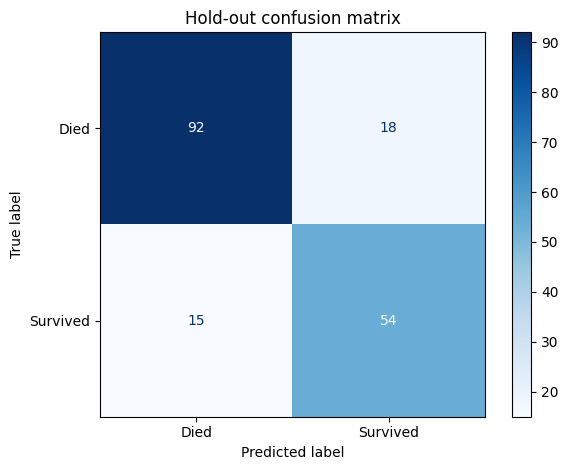

In [11]:
_ = rf_ticket_pipeline.fit(X_train_context, y_train)
holdout_proba = rf_ticket_pipeline.predict_proba(X_holdout_context)[:, 1]
holdout_pred = (holdout_proba >= best_threshold).astype(int)

holdout_metrics = pd.Series({
    'accuracy': accuracy_score(y_holdout, holdout_pred),
    'precision': precision_score(y_holdout, holdout_pred),
    'recall': recall_score(y_holdout, holdout_pred),
    'f1': f1_score(y_holdout, holdout_pred),
    'roc_auc': roc_auc_score(y_holdout, holdout_proba),
})
display(holdout_metrics.round(3))
print(classification_report(y_holdout, holdout_pred))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_holdout, holdout_pred),
    display_labels=['Died', 'Survived'],
).plot(cmap='Blues')
plt.title('Hold-out confusion matrix')
plt.tight_layout()
plt.savefig(ASSET_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

## 8. 전체 train 재학습과 Kaggle 제출 생성

Kaggle test에는 `Survived`가 없다. 따라서 내부 검증이 아니라, 선택이 끝난 모델을 891명 전체로 다시 학습해 418명의 제출 예측을 만든다.

In [12]:
X_all_context = add_context_features(X)
X_kaggle_context = add_context_features(kaggle_test_df)

_ = rf_ticket_pipeline.fit(X_all_context, y)
kaggle_proba = rf_ticket_pipeline.predict_proba(X_kaggle_context)[:, 1]
submission = pd.DataFrame({
    'PassengerId': kaggle_test_df['PassengerId'],
    'Survived': (kaggle_proba >= best_threshold).astype(int),
})
submission_path = PROJECT_ROOT / 'submission.csv'
submission.to_csv(submission_path, index=False)

assert submission.columns.tolist() == ['PassengerId', 'Survived']
assert len(submission) == 418
assert set(submission['Survived']) <= {0, 1}
print('saved:', submission_path)
submission.head()

saved: D:\dev\03_PersonalProjects\titanic-survival-prediction\submission.csv


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


## 한계

교차검증에서 학습 Fold에 없던 티켓은 그룹 크기 1로 처리했다. 또한 승객 단위 무작위 분할을 사용했기 때문에 같은 티켓의 승객이 서로 다른 Fold에 배치될 수 있다. 따라서 티켓 동행 정보의 일반화 가능성에는 제약이 있으며, 후속 실험에서는 티켓 단위 분할을 검토할 수 있다.